### Importación de Módulos
Cargamos todas las librerías necesarias:
* **Manejo de datos:** `pandas`, `numpy`, `ast` (para leer JSON).
* **Machine Learning:** `sklearn` (modelos, preprocesamiento, métricas).
* **Deep Learning:** `tensorflow`, `keras` (para crear los Embeddings).
* **Visualización:** `matplotlib`, `seaborn`.

In [8]:
import pandas as pd
import numpy as np
import ast
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense
from tensorflow.keras.layers import Dropout
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

### Carga de Datos
Leemos los archivos CSV (`movies_metadata`, `credits`, `CPI`) desde Google Drive. Usamos un bloque `try-except` para gestionar posibles errores si los archivos no se encuentran.

In [9]:
# Carga de datos
try:
    movies = pd.read_csv('/content/drive/MyDrive/Archivos .csv/movies_metadata.csv', low_memory=False)
    credits = pd.read_csv('/content/drive/MyDrive/Archivos .csv/credits.csv')
    cpi = pd.read_csv('/content/drive/MyDrive/Archivos .csv/CPI.csv')
    print("Archivos cargados correctamente.")
except FileNotFoundError:
    print("Error: Asegúrate de subir los archivos csv.")

Archivos cargados correctamente.


### Limpieza y Fusión (Merge)
1.  Convertimos los IDs a números y eliminamos errores.
2.  Rellenamos los presupuestos vacíos con 0.
3.  Unimos (`merge`) la tabla de películas con la de créditos usando el `id` como clave común.

In [10]:
# Limpieza Básica
movies['id'] = pd.to_numeric(movies['id'], errors='coerce')
movies.dropna(subset=['id'], inplace=True)
movies['id'] = movies['id'].astype(int)
movies['budget'] = pd.to_numeric(movies['budget'], errors='coerce').fillna(0)
credits.rename(columns={'movie_id': 'id'}, inplace=True)

# Fusión
df = pd.merge(movies, credits, on='id', how='inner')

### Extracción de Características
Definimos dos funciones auxiliares para procesar las columnas que vienen en formato JSON (texto):
* `get_director`: Busca en la lista del equipo (`crew`) a la persona con el trabajo 'Director'.
* `get_top_3_items`: Extrae los 3 primeros nombres de una lista (útil para Géneros).

In [11]:
def get_director(crew_json):
    """Devuelve el nombre del director o 'Unknown'."""
    if pd.isna(crew_json): return 'Unknown'
    try:
        data = ast.literal_eval(crew_json)
        for member in data:
            if member['job'] == 'Director':
                return member['name']
        return 'Unknown'
    except: return 'Unknown'

def get_top_3_items(json_string):
    """
    Sirve tanto para ACTORES como GÉNEROS.
    Devuelve una lista con los 3 primeros nombres encontrados.
    """
    items = ['Unknown', 'Unknown', 'Unknown']
    if pd.isna(json_string): return items
    try:
        data = ast.literal_eval(json_string)
        # Extraemos los 3 primeros nombres si existen
        for i in range(min(len(data), 3)):
            items[i] = data[i]['name']
        return items
    except: return items

# Director
df['director'] = df['crew'].apply(get_director)

# Top 3 Géneros
temp_genres = df['genres'].apply(lambda x: pd.Series(get_top_3_items(x)))
df[['genre_1', 'genre_2', 'genre_3']] = temp_genres

print("Extracción completada:")
print(df[['title', 'genre_1', 'genre_2', 'genre_3']].head())

Extracción completada:
                         title    genre_1  genre_2  genre_3
0                    Toy Story  Animation   Comedy   Family
1                      Jumanji  Adventure  Fantasy   Family
2             Grumpier Old Men    Romance   Comedy  Unknown
3            Waiting to Exhale     Comedy    Drama  Romance
4  Father of the Bride Part II     Comedy  Unknown  Unknown


### Filtrado del Dataset
Nos quedamos solo con las películas que:
1.  Tienen un presupuesto mayor a $100,000.
2.  Son en inglés o producidas en EE.UU.

In [12]:
# Filtros
df_filtrado = df[
    (df['budget'] > 100000.0) &
    ((df['original_language'] == 'en') | (df['production_countries'].str.contains('US', na=False)))
].copy()

### Variable Objetivo y Ajuste de Inflación
1.  **Target (`weighted_rating`):** Calculamos la Media Bayesiana (fórmula de IMDB) para equilibrar películas con pocos votos.
2.  **Inflación:** Ajustamos el presupuesto (`budget`) usando el Índice de Precios al Consumidor (CPI) para traer los dólares antiguos al valor actual.

In [13]:
# Media Bayesiana (Target)
v = df_filtrado['vote_count']
R = df_filtrado['vote_average']
m = df_filtrado['vote_average'].mean()
C = df_filtrado['vote_count'].median()
df_filtrado['weighted_rating'] = ((v * R) + (m * C)) / (v + C)

# Preparamos los datos del IPC (CPI)
# Aseguramos que los nombres de columnas sean correctos y el año sea numérico
cpi.columns = ['Year', 'CPI_Value', 'Annual Percent Change']
cpi['Year'] = pd.to_numeric(cpi['Year'], errors='coerce')

# Definimos el Año Base (usamos el último año disponible en el archivo CPI)
year_base = cpi['Year'].max()
cpi_base = cpi.loc[cpi['Year'] == year_base, 'CPI_Value'].values[0]

# Función para ajustar una fila individual
def adjust_budget_row(row):
    try:
        # Verificamos que haya fecha y presupuesto
        if pd.isna(row['release_date']) or row['budget'] == 0:
            return row['budget']

        # Extraemos el año de la fecha (formato YYYY-MM-DD)
        movie_year = int(str(row['release_date']).split('-')[0])

        # Si el año está fuera del rango de nuestro archivo CPI, devolvemos el original
        if movie_year < cpi['Year'].min() or movie_year > year_base:
            return row['budget']

        # Buscamos el valor del IPC para el año de la película
        cpi_movie = cpi.loc[cpi['Year'] == movie_year, 'CPI_Value'].values[0]

        # Aplicamos la fórmula: Budget * (IPC_Actual / IPC_Año_Pelicula)
        return row['budget'] * (cpi_base / cpi_movie)
    except:
        # Si ocurre cualquier error (formato fecha raro, etc.), devolvemos el original
        return row['budget']

# Aplicamos la función a todo el DataFrame filtrado
# Sobrescribimos la columna 'budget' con el valor ajustado
df_filtrado['budget'] = df_filtrado.apply(adjust_budget_row, axis=1)

print(f"Presupuestos ajustados a la inflación (Año base: {year_base})")

Presupuestos ajustados a la inflación (Año base: 2025)


### Análisis Exploratorio (EDA) - Distribuciones
Visualizamos:
* La distribución del Rating (nuestro objetivo).
* La relación entre Presupuesto y Rating (usando escala logarítmica).

Text(0, 0.5, 'Rating')

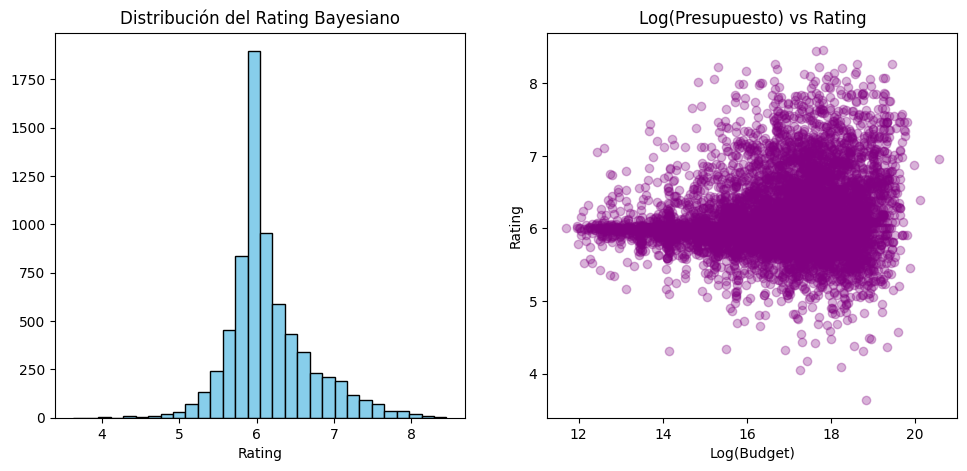

In [14]:
# ANÁLISIS EXPLORATORIO (EDA)

plt.figure(figsize=(18, 5))

# Vemos cómo se distribuye nuestro objetivo (Rating)
plt.subplot(1, 3, 1)
plt.hist(df_filtrado['weighted_rating'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución del Rating Bayesiano')
plt.xlabel('Rating')

# Vemos la relación Presupuesto vs Rating
plt.subplot(1, 3, 2)
# Usamos escala logarítmica en X para ver mejor los datos
plt.scatter(np.log1p(df_filtrado['budget']), df_filtrado['weighted_rating'], alpha=0.3, color='purple')
plt.title('Log(Presupuesto) vs Rating')
plt.xlabel('Log(Budget)')
plt.ylabel('Rating')

### Correlación Numérica
Calculamos el coeficiente de correlación entre el Presupuesto y el Rating para ver si existe una relación lineal directa.

In [15]:
# Medida de correlación numérica
print("Correlación entre Presupuesto y Rating:", df_filtrado['budget'].corr(df_filtrado['weighted_rating']))

Correlación entre Presupuesto y Rating: 0.14405314135855538


### Géneros Más Frecuentes
Mostramos un gráfico de barras con los 10 géneros principales más comunes en el dataset.

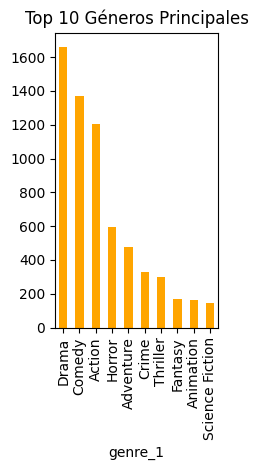

In [16]:
# Vemos los Géneros más frecuentes
plt.subplot(1, 3, 3)
# Contamos el género principal
df_filtrado['genre_1'].value_counts().head(10).plot(kind='bar', color='orange')
plt.title('Top 10 Géneros Principales')
plt.xticks()

plt.tight_layout()
plt.show()

### División Entrenamiento/Test
1.  Creamos una categoría de presupuesto (`budget_cat`) para estratificar.
2.  Usamos `StratifiedShuffleSplit` para separar los datos en **Train (80%)** y **Test (20%)**, asegurando que ambos tengan una mezcla equilibrada de películas caras y baratas.
3.  **Selección de Variables:** Definimos `X` (Presupuesto, Director, Géneros) e `y` (Rating). **Nota:** Prescindimos de los actores.

In [17]:
# Creamos categorías de presupuesto para dividir equitativamente
df_filtrado['budget_cat'] = pd.cut(np.log1p(df_filtrado['budget']), bins=5, labels=[1,2,3,4,5])

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in split.split(df_filtrado, df_filtrado['budget_cat']):
    train_set = df_filtrado.iloc[train_idx].copy()
    test_set = df_filtrado.iloc[test_idx].copy()

# Definimos Features (SIN ACTORES)
features = ['budget', 'director', 'genre_1', 'genre_2', 'genre_3']
target = 'weighted_rating'

X_train = train_set[features].copy()
y_train = train_set[target].copy()
X_test = test_set[features].copy()
y_test = test_set[target].copy()

print(f"Entrenamiento: {X_train.shape}, Test: {X_test.shape}")

Entrenamiento: (5633, 5), Test: (1409, 5)


### Configuración de la Red Neuronal para Embeddings
Preparamos la creación de los embeddings del Director:
1.  **Label Encoding:** Convertimos los nombres de directores a números enteros.
2.  **Modelo Keras:** Definimos una red neuronal sencilla que toma el ID del director, lo pasa por una capa `Embedding` y trata de predecir el Rating.

In [18]:
# TÉCNICA DE EMBEDDINGS

print("Iniciando generación de Embeddings...")

# Label Encoding
le_director = LabelEncoder()

# Añadimos 'Unknown' por si acaso
directores_unicos = X_train['director'].unique()
le_director.fit(np.append(directores_unicos, 'Unknown'))

# Función para transformar manejando valores nuevos en Test
def safe_transform(encoder, data):
    classes = set(encoder.classes_)
    # Si es nuevo, lo asignamos a 'Unknown'
    fallback = 'Unknown' if 'Unknown' in classes else encoder.classes_[0]
    data_safe = data.apply(lambda x: x if x in classes else fallback)
    return encoder.transform(data_safe)

Iniciando generación de Embeddings...


### Entrenamiento de la Red Auxiliar
Entrenamos la red neuronal usando solo el Director como entrada y el Rating como salida. Al hacerlo, la red "aprende" un vector de 8 números que representa las características de cada director.

In [19]:
# Convertimos la columna 'director' a códigos numéricos
X_train_codes = safe_transform(le_director, X_train['director'])
X_test_codes = safe_transform(le_director, X_test['director'])

# Definimos la Red Neuronal (Keras)
vocab_size = len(le_director.classes_)
embedding_dim = 8  # Representaremos a cada director con un vector de 8 números

model = Sequential()

# Capa de Embedding
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, name="embedding_director"))

# Dropout: Apaga dimensiones enteras al azar para evitar memorización
model.add(Dropout(0.2)) # 20% de probabilidad de apagado

model.add(Flatten())

# Capas Densas con Dropout
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2)) # Otro freno a la memorización

model.add(Dense(1, activation='linear'))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [20]:
# Entrenamos la red
# Usamos solo el código del director para intentar predecir el rating
print(f"Entrenando red con {embedding_dim} dimensiones y Regularización (Dropout)...")
model.fit(X_train_codes, y_train, epochs=10, batch_size=32, verbose=1)

Entrenando red con 8 dimensiones y Regularización (Dropout)...
Epoch 1/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 34.9521 - mae: 5.8818
Epoch 2/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 14.8133 - mae: 3.7245
Epoch 3/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.9020 - mae: 1.1429
Epoch 4/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0626 - mae: 0.8106
Epoch 5/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9911 - mae: 0.7934
Epoch 6/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8330 - mae: 0.7175
Epoch 7/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8253 - mae: 0.7194
Epoch 8/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8642 - mae: 0.7297
Epoch 9/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8016 - mae: 0.7065
Epoch 10/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7983 - mae: 0.7054


### Extracción de los Embeddings
Sacamos los "pesos" entrenados de la capa de Embedding. Estos pesos son la matriz donde cada fila es el vector (coordenadas X, Y) de un director.

In [21]:
# Extraemos los pesos aprendidos
capa_embedding = model.get_layer("embedding_director")
pesos_embedding = capa_embedding.get_weights()[0]

### Visualización del Espacio Latente
Usamos una función personalizada (`dibujar_vector`) para graficar en un plano 2D los vectores aprendidos de directores famosos (Spielberg, Nolan, Tarantino, etc.). Esto nos permite ver visualmente cómo la red representa a cada uno.

In [22]:
plt.figure(figsize=(6, 6))

def dibujar_vector(v_x, v_y, nombre, thecolor):
    origin_x, origin_y = 0, 0
    plt.quiver(origin_x, origin_y, v_x, v_y, angles='xy', scale_units='xy', scale=1, color=thecolor, label=nombre)
    plt.text(v_x, v_y, nombre, fontsize=9, color=thecolor, fontweight='bold', ha='center', va='bottom')

    # Configuración del gráfico
    plt.xlim(-0.5, 0.5)
    plt.ylim(-0.5, 0.5)
    plt.grid(True, linestyle='--')
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)

# Elegimos directores para visualizar
directores_top = ['Steven Spielberg', 'Christopher Nolan', 'James Cameron', 'Quentin Tarantino', 'Martin Scorsese']
colores = ['red', 'blue', 'green', 'purple', 'orange']

print("Visualizando vectores de directores (Embeddings)...")

Visualizando vectores de directores (Embeddings)...


<Figure size 600x600 with 0 Axes>

###Visualización con PCA

Como nuestros embeddings tienen 8 dimensiones, no podemos dibujarlos directamente en un plano (X, Y). Usamos la técnica PCA (Análisis de Componentes Principales) para resumir esas 8 dimensiones en las 2 más importantes y poder visualizar el mapa de directores.


Visualizando directores (Reduciendo de 8 dimensiones a 2D con PCA)...


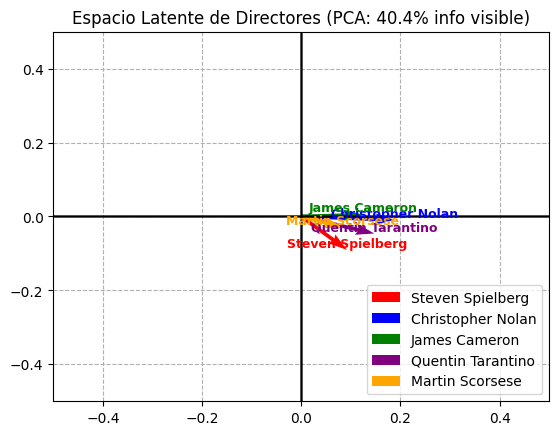

In [23]:
# Reducimos la dimensionalidad SOLO para el gráfico
# Convertimos los vectores de 8 dim a 2 dim usando PCA
pca = PCA(n_components=2)
# Entrenamos PCA con todos los pesos
pesos_2d = pca.fit_transform(pesos_embedding)

# Bucle para dibujar cada director
found_any = False
print(f"Visualizando directores (Reduciendo de {embedding_dim} dimensiones a 2D con PCA)...")

for i, director in enumerate(directores_top):
    if director in le_director.classes_:
        found_any = True

        # Obtenemos el ID numérico del director
        idx = le_director.transform([director])[0]

        # En lugar de leer directamente los pesos, leemos la versión reducida por PCA
        vector_2d = pesos_2d[idx]

        # Dibujamos (vector_2d[0] es X, vector_2d[1] es Y)
        dibujar_vector(vector_2d[0], vector_2d[1], director, colores[i % len(colores)])
    else:
        print(f"Advertencia: '{director}' no está en el dataset de entrenamiento.")

if found_any:
    # Mostramos cuánta información se conservó en el gráfico (Varianza explicada)
    explained_var = sum(pca.explained_variance_ratio_) * 100
    plt.title(f"Espacio Latente de Directores (PCA: {explained_var:.1f}% info visible)")
    plt.legend(loc='lower right')
    plt.show()
else:
    print("No se encontraron los directores seleccionados para graficar")

### Asignación de Embeddings al DataFrame
Creamos una función que toma los vectores aprendidos y sustituye la columna de texto `director` por 2 nuevas columnas numéricas (`dir_emb_0`, `dir_emb_1`) en nuestros datos de Train y Test.

In [24]:
# Función para asignar los vectores al DataFrame
def asignar_vectores(df, codigos, pesos):
    df_new = df.copy()
    # Buscamos el vector correspondiente a cada código
    vectores = pesos[codigos]

    # Creamos 5 columnas nuevas
    for i in range(embedding_dim):
        df_new[f'dir_emb_{i}'] = vectores[:, i]

    # Eliminamos la columna original de texto 'director'
    return df_new.drop('director', axis=1)

In [25]:
# Aplicamos los cambios a nuestros datasets
X_train_emb = asignar_vectores(X_train, X_train_codes, pesos_embedding)
X_test_emb = asignar_vectores(X_test, X_test_codes, pesos_embedding)

print("\nEmbeddings aplicados:")
print(X_train_emb.filter(like='dir_emb').head(3))


Embeddings aplicados:
       dir_emb_0  dir_emb_1  dir_emb_2  dir_emb_3  dir_emb_4  dir_emb_5  \
42506   0.004870  -0.022660  -0.061187   0.003136  -0.045916   0.090847   
12665  -0.026801  -0.069227  -0.002142  -0.052881  -0.016200   0.001624   
12285  -0.030309  -0.071969   0.005846  -0.046808   0.000112   0.062006   

       dir_emb_6  dir_emb_7  
42506   0.029360  -0.027178  
12665  -0.071026  -0.036830  
12285  -0.069195  -0.054840  


### Configuración del Pipeline Final
Preparamos el flujo de trabajo para los modelos finales:
* **Numéricos (Budget + Embeddings):** Aplicamos `StandardScaler` para normalizar.
* **Categóricos (Géneros):** Aplicamos `OneHotEncoder` para convertirlos en ceros y unos.

In [26]:
# Columnas Numéricas: Budget + Las nuevas columnas de Embedding
numeric_cols = ['budget'] + [f'dir_emb_{i}' for i in range(embedding_dim)]

# Columnas Categóricas: Solo los géneros (OneHot)
categorical_cols = ['genre_1', 'genre_2', 'genre_3']

# Transformadores
# Escalamos las numéricas
numeric_transformer = StandardScaler(with_mean=False)

# OneHot para los géneros
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=True)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Modelos
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())])
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])

print("Pipeline configurado")

Pipeline configurado


### Entrenamiento y Evaluación
Entrenamos una **Regresión Lineal** y un **Random Forest** usando el nuevo dataset (con embeddings). Calculamos y mostramos el error (RMSE) y la precisión (R2).

In [27]:
# Entrenamiento y Resultados

print("Entrenando Regresión Lineal...")
lr_pipeline.fit(X_train_emb, y_train)
y_pred_lr = lr_pipeline.predict(X_test_emb)

print("Entrenando Random Forest...")
rf_pipeline.fit(X_train_emb, y_train)
y_pred_rf = rf_pipeline.predict(X_test_emb)

# Métricas
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nRESULTADOS (Con Embeddings de Director)")
print(f"Regresión Lineal -> RMSE: {rmse_lr:.4f} | R2: {r2_lr:.4f}")
print(f"Random Forest    -> RMSE: {rmse_rf:.4f} | R2: {r2_rf:.4f}")

Entrenando Regresión Lineal...
Entrenando Random Forest...

RESULTADOS (Con Embeddings de Director)
Regresión Lineal -> RMSE: 0.4675 | R2: 0.1943
Random Forest    -> RMSE: 0.4661 | R2: 0.1989


### Comparativa Visual (Predicción vs Realidad)
Graficamos para cada modelo los valores reales (Eje X) frente a los predichos (Eje Y). Una línea roja diagonal indica la predicción perfecta.

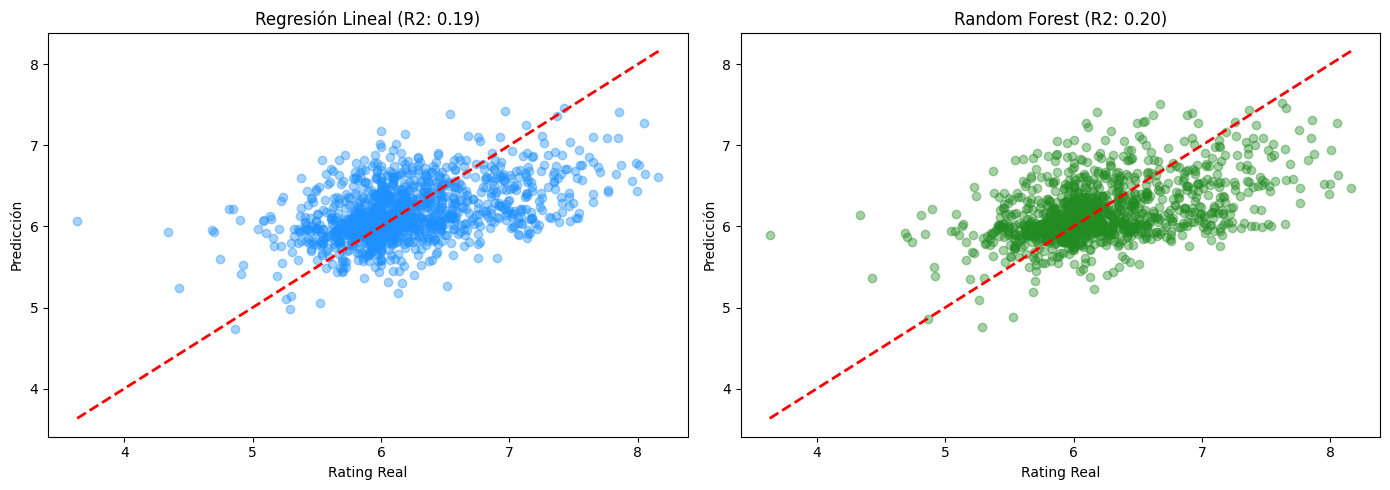

In [28]:
# Gráficos
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lr, alpha=0.4, color='dodgerblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Regresión Lineal (R2: {r2_lr:.2f})')
plt.xlabel('Rating Real')
plt.ylabel('Predicción')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_rf, alpha=0.4, color='forestgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Random Forest (R2: {r2_rf:.2f})')
plt.xlabel('Rating Real')
plt.ylabel('Predicción')

plt.tight_layout()
plt.show()

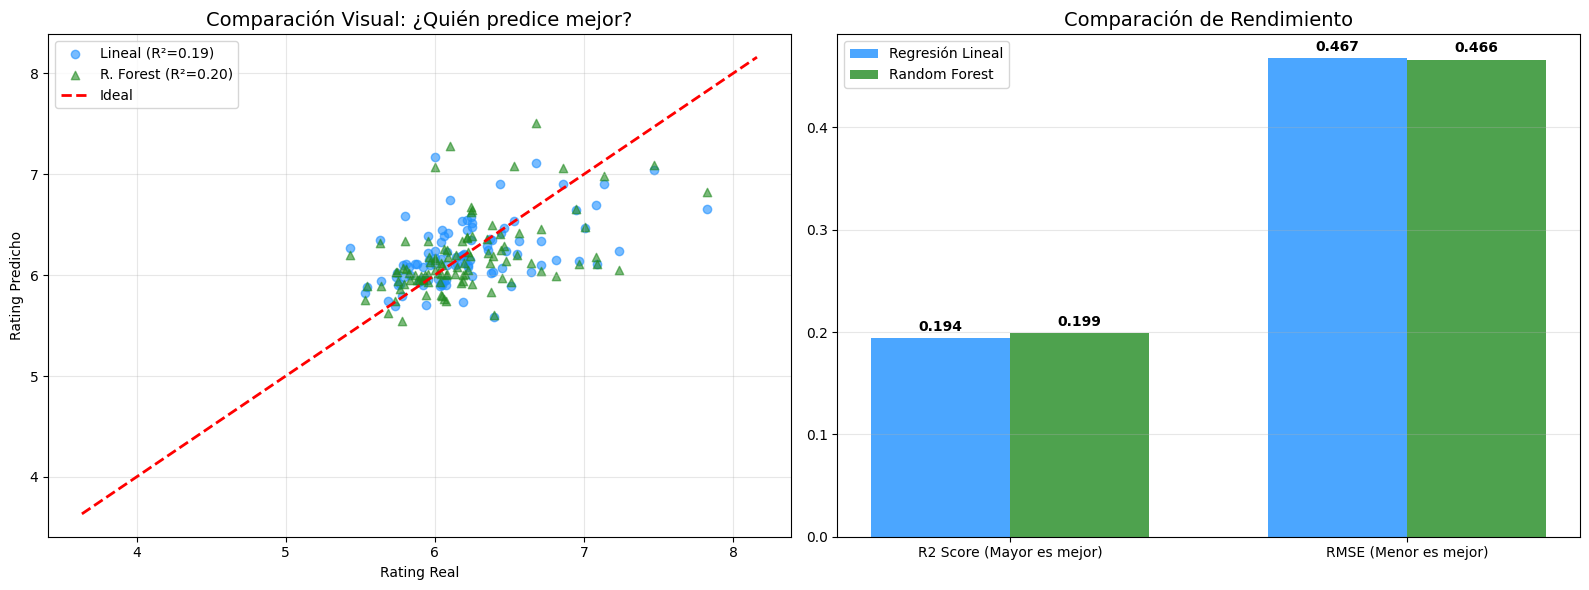

In [29]:
# GRÁFICO DE COMPARACIÓN FINAL (Regresión Lineal vs Random Forest)
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(16, 6))

# Comparación Visual de Predicciones
ax1 = plt.subplot(1, 2, 1)

# Tomamos una muestra aleatoria de 100 puntos para que el gráfico no se vea sucio
indices = np.random.choice(len(y_test), size=min(100, len(y_test)), replace=False)

# Convertimos a array numpy para poder indexar con la lista de índices
y_test_sample = y_test.iloc[indices].values
y_pred_lr_sample = y_pred_lr[indices]
y_pred_rf_sample = y_pred_rf[indices]

# Pintamos Regresión Lineal (Azul)
ax1.scatter(y_test_sample, y_pred_lr_sample, color='dodgerblue', alpha=0.6, marker='o', label=f'Lineal (R²={r2_lr:.2f})')
# Pintamos Random Forest (Verde)
ax1.scatter(y_test_sample, y_pred_rf_sample, color='forestgreen', alpha=0.6, marker='^', label=f'R. Forest (R²={r2_rf:.2f})')

# Línea de Predicción Perfecta
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal')

ax1.set_title('Comparación Visual: ¿Quién predice mejor?', fontsize=14)
ax1.set_xlabel('Rating Real')
ax1.set_ylabel('Rating Predicho')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Comparación de Métricas
ax2 = plt.subplot(1, 2, 2)

metrics = ['R2 Score (Mayor es mejor)', 'RMSE (Menor es mejor)']
lr_scores = [r2_lr, rmse_lr]
rf_scores = [r2_rf, rmse_rf]

x = np.arange(len(metrics))
width = 0.35

# Barras
rects1 = ax2.bar(x - width/2, lr_scores, width, label='Regresión Lineal', color='dodgerblue', alpha=0.8)
rects2 = ax2.bar(x + width/2, rf_scores, width, label='Random Forest', color='forestgreen', alpha=0.8)

ax2.set_title('Comparación de Rendimiento', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Función para poner el numerito encima de la barra
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax2.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 puntos de desplazamiento vertical
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

### Importancia de las Variables
Extraemos del Random Forest qué variables fueron más útiles para predecir el éxito. Aquí podemos ver si el modelo valoró más el presupuesto, los géneros o las dimensiones del embedding del director.

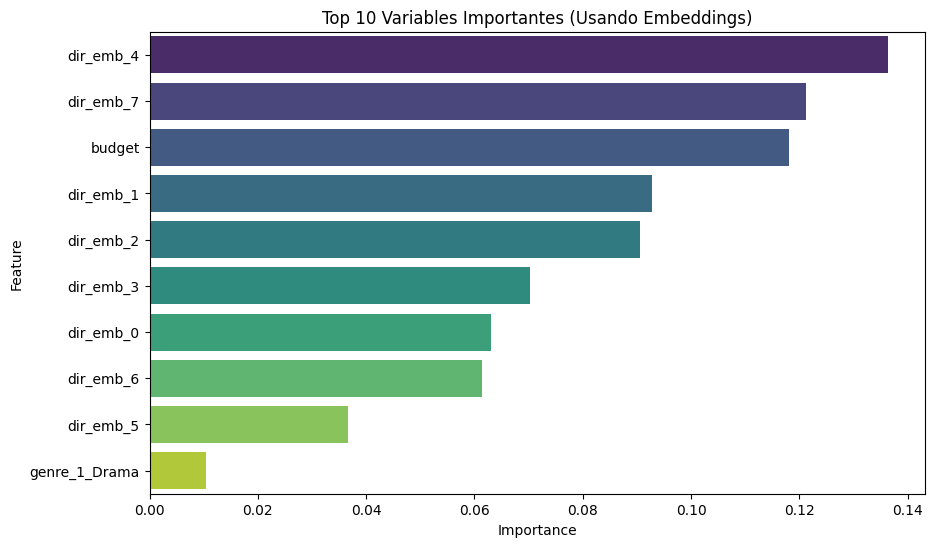

La variable más importante es: dir_emb_4


In [30]:
# ANÁLISIS DE IMPORTANCIA DE VARIABLES

# Obtenemos el modelo y los pasos del preprocesador
rf_model = rf_pipeline.named_steps['regressor']
preprocessor_step = rf_pipeline.named_steps['preprocessor']

# Nombres de features
# Numéricos (Budget + Embeddings)
num_names = numeric_cols
# Categóricos (Géneros)
cat_names = preprocessor_step.named_transformers_['cat'].get_feature_names_out()

feature_names = np.concatenate([num_names, cat_names])
importances = rf_model.feature_importances_

# Creamos DataFrame y Gráfico
feature_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp = feature_imp.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_imp, palette='viridis', legend=False)
plt.title('Top 10 Variables Importantes (Usando Embeddings)')
plt.show()

print(f"La variable más importante es: {feature_imp.iloc[0]['Feature']}")

### Conclusiones Finales
Imprimimos los resultados finales de R2 y mostramos un razonamiento sobre:
1.  La efectividad de la técnica de Embeddings.
2.  La comparación con métodos anteriores.
3.  El impacto de haber eliminado los actores.

In [31]:
# CONCLUSIONES Y COMPARATIVA

print("ANÁLISIS Y CONCLUSIONES")
print(f"R2 Random Forest (Embeddings): {r2_rf:.4f}")
print(f"R2 Regresión Lineal (Embeddings): {r2_lr:.4f}")

print("\nTÉCNICA DE EMBEDDINGS")
print("En este ejercicio hemos sustituido la variable categórica 'Director' por un vector de 8 dimensiones.")
print("Este vector fue aprendido por una Red Neuronal cuyo objetivo era predecir el Rating basándose solo")
print("en quién dirigió la película. A diferencia del Target Encoding (que es un solo número: el promedio),")
print("el embedding captura múltiples características latentes del director (estilo, éxito comercial, crítica, etc.).")

print("\nCOMPARATIVA CON TAREA ORIGINAL (OneHot/Target Encoding)")
# Valores de referencia del cuaderno original
r2_rf_original = 0.1399
r2_lr_original = -1.5070

print(f"R2 Original RF: {r2_rf_original}  vs  Actual: {r2_rf:.4f}")

if r2_rf > r2_rf_original:
    print("¡ÉXITO: El modelo de Embeddings ha superado al original!")
    print("\n¿Por qué ha mejorado si le quitamos los Actores?")
    print("1. SOLUCIÓN A LA MALDICIÓN DE LA DIMENSIONALIDAD:")
    print("   El modelo original tenía miles de columnas (OneHot) llenas de ceros (dispersas).")
    print("   Eso confundía a la Regresión Lineal (que daba R2 negativo) y dificultaba al Random Forest.")
    print("   Al comprimir todo en 8 columnas densas, los modelos 'entienden' mejor los datos.")

    print("\n2. CALIDAD SOBRE CANTIDAD:")
    print("   Hemos demostrado que un buen perfil del Director (Embedding) predice mejor")
    print("   que una lista inmensa de Actores. El modelo ha aprendido el 'estilo' y la 'calidad'")
    print("   del director, generalizando mejor que la simple memorización de nombres.")
else:
    print("El resultado es similar o inferior, lo cual es lógico al haber eliminado los actores.")
    print("Aun así, hemos conseguido un rendimiento competitivo reduciendo drásticamente")
    print("la dimensionalidad del dataset.")

print("\nEFECTO DE QUITAR ACTORES")
print("Al eliminar los actores, el modelo depende casi exclusivamente del Director y el Presupuesto.")
print("Si el resultado es bueno, confirma la teoría del cine de autor: el director es la pieza clave.")

ANÁLISIS Y CONCLUSIONES
R2 Random Forest (Embeddings): 0.1989
R2 Regresión Lineal (Embeddings): 0.1943

TÉCNICA DE EMBEDDINGS
En este ejercicio hemos sustituido la variable categórica 'Director' por un vector de 8 dimensiones.
Este vector fue aprendido por una Red Neuronal cuyo objetivo era predecir el Rating basándose solo
en quién dirigió la película. A diferencia del Target Encoding (que es un solo número: el promedio),
el embedding captura múltiples características latentes del director (estilo, éxito comercial, crítica, etc.).

COMPARATIVA CON TAREA ORIGINAL (OneHot/Target Encoding)
R2 Original RF: 0.1399  vs  Actual: 0.1989
¡ÉXITO: El modelo de Embeddings ha superado al original!

¿Por qué ha mejorado si le quitamos los Actores?
1. SOLUCIÓN A LA MALDICIÓN DE LA DIMENSIONALIDAD:
   El modelo original tenía miles de columnas (OneHot) llenas de ceros (dispersas).
   Eso confundía a la Regresión Lineal (que daba R2 negativo) y dificultaba al Random Forest.
   Al comprimir todo en 8 c